# Data Trimming

Measured data sets often contain unnecessary or undesirable values. Therefore, it is good practice to pre-process data sets so that they contain only well-conditioned data for analysis. We call this process "trimming."

## Learning Points

In this chapter, you will learn about:

* ssd.plot_trimming_info()
* ssd.plot_compact()
* Moment
* ssd.trimmed_copy()

## Overview of the Data

The data set used here for explanation looks like this.

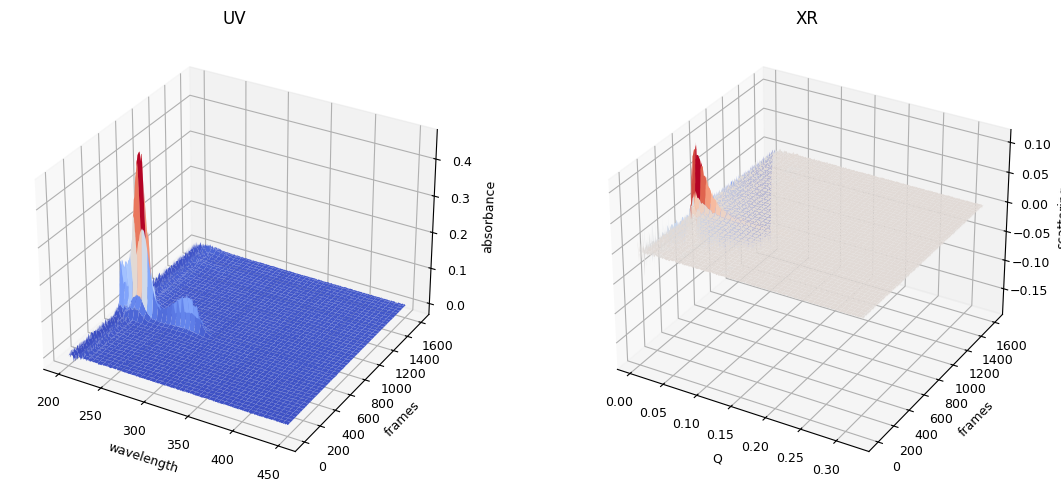

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from molass.Local import get_local_settings
from molass.DataObjects import SecSaxsData as SSD
local_settings = get_local_settings()
PKS_DATA = local_settings['PKS_DATA']
ssd = SSD(PKS_DATA)
ssd.plot_3d();

## Plotting Trimming Ranges

You can plot the default trimming ranges as follows.

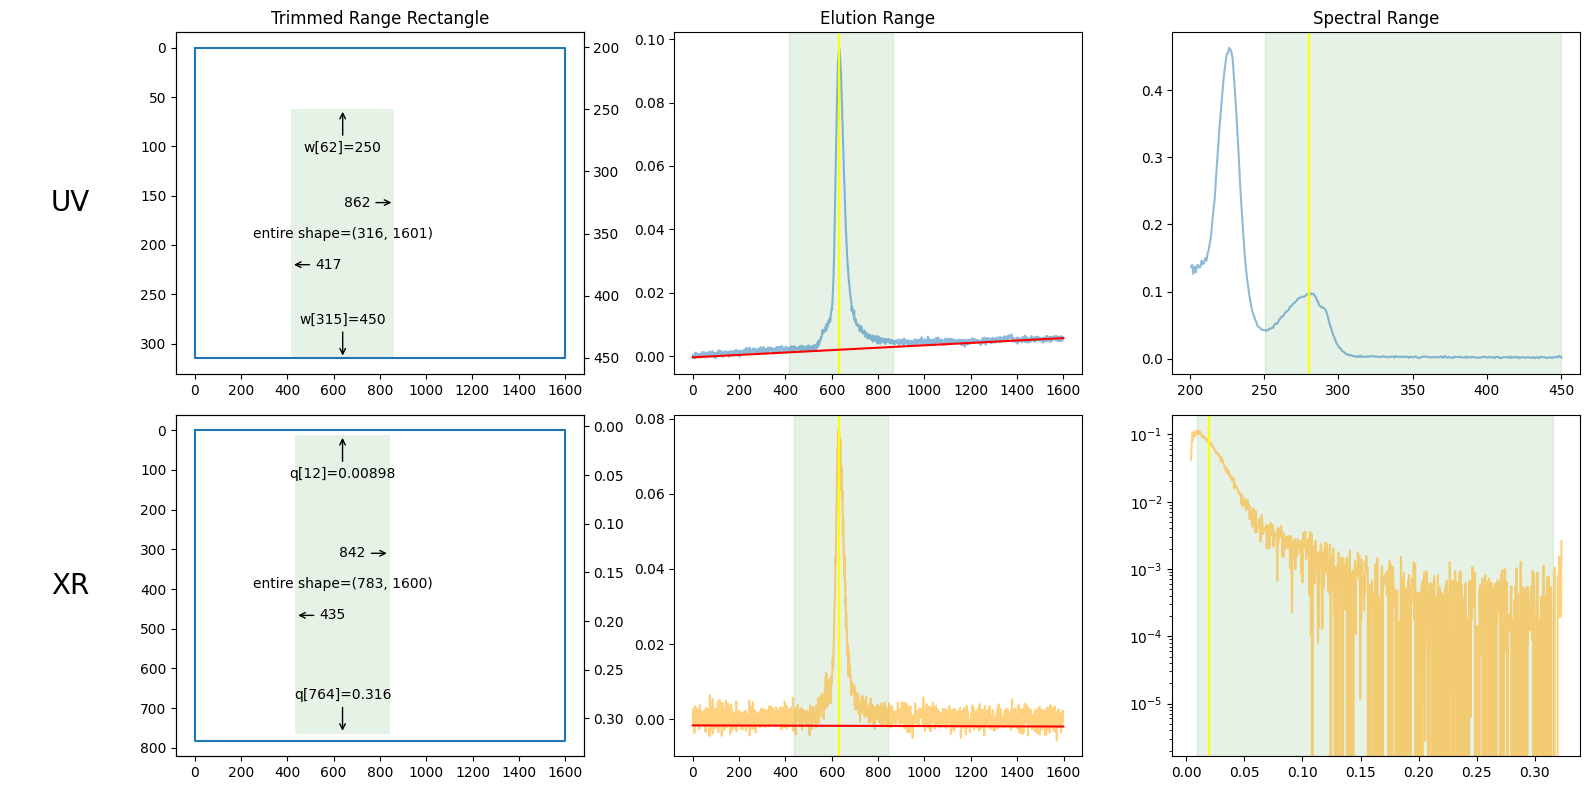

In [2]:
ssd.plot_trimming_info();

The above figures show the trimming ranges in three distinct flavors. On the left, as rectangles suggesting rows and columns in matrices, in the center as vertical bands against elution curves and on the right as vertical bands against spectral curves (an absorbance curve or a scattering curve).

The elution range has been chosen so that you can focus on the peak region with sufficient baseline regions.

The wavelength range shorter than 250nm in UV absorbance has been cut off due to unstable measurement often observed there.

Both ends in X-ray scatttering angles have been cut off due to irregular values.

The center figures also show baselines in red lines, which will be explained in the following chapters.

More compact plots are availabe as follows.

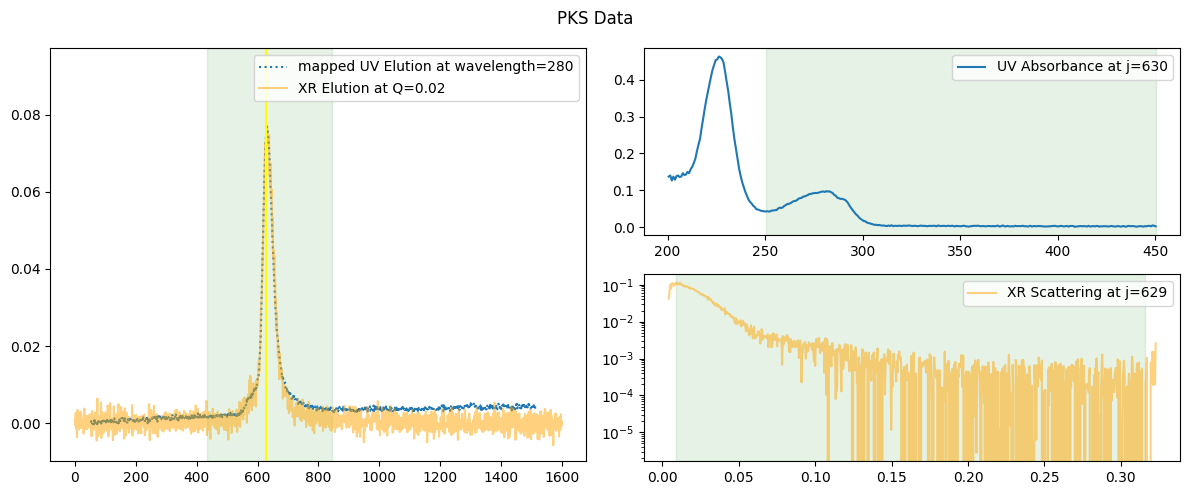

In [3]:
ssd.plot_compact(title="PKS Data");


In this compact form, the mapping between UV and X-ray elution points is more apparent. We will discuss this mapping in a later chapter.

## Trimming in Elution Axis
### Trimming by Moment

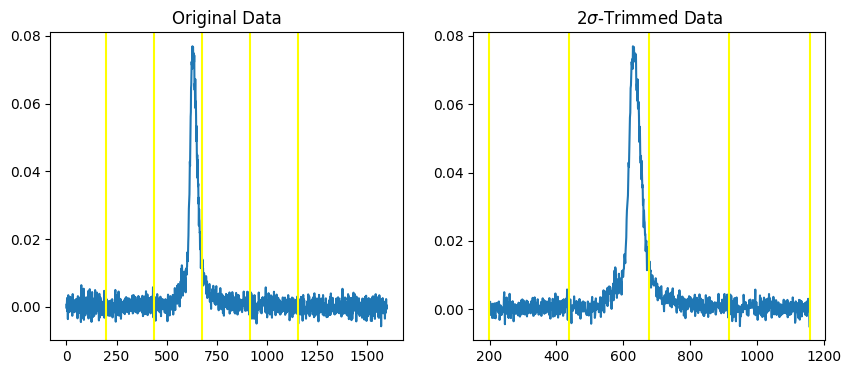

In [4]:
from molass.Stats import Moment
xr_icurve = ssd.xr.get_icurve()
uv_icurve = ssd.uv.get_icurve()
x = xr_icurve.x
y = xr_icurve.y
mt = Moment(x, y)
mean, std = mt.get_meanstd()
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(10,4))
ax1.set_title("Original Data")
ax2.set_title(r"2$\sigma$-Trimmed Data")
ax1.plot(x, y)
wanted_range = np.logical_and(mean-2*std < x, x < mean+2*std)
ax2.plot(x[wanted_range], y[wanted_range])
for p in [mean-2*std, mean-std, mean, mean+std, mean+2*std]:
    for ax in ax1, ax2:
        ax.axvline(p, color='yellow')

In [5]:
mt.get_nsigma_points(2)

(199, 1157)

### Trimming by Flow Change

This type of trimmming is required only for those data from special experiments where flow change operation is in practice.
See [Flow Change Detection](flowchange_detection) if necessary.

## Trimming in Spectral Axis

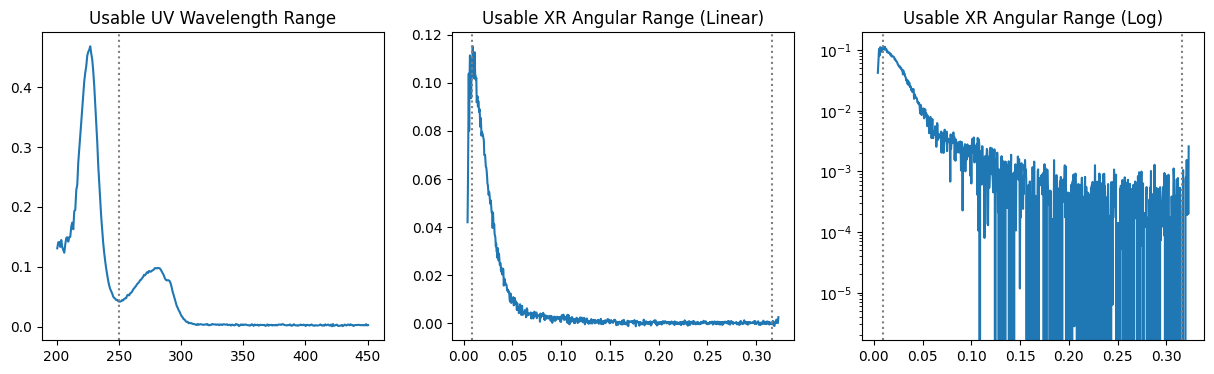

In [6]:
# ssd from sample_data
fig, (ax1,ax2,ax3) = plt.subplots(ncols=3, figsize=(15,4))

ax1.set_title("Usable UV Wavelength Range")
i, j = ssd.uv.get_usable_wrange()
k = np.argmax(uv_icurve.y)
uv_jcurve = ssd.uv.get_jcurve(j=k)
ax1.plot(uv_jcurve.x, uv_jcurve.y)
for n in i, j:
    if n is not None:
        ax1.axvline(uv_jcurve.x[n], ls=":", color='gray')

ax2.set_title("Usable XR Angular Range (Linear)")
ax3.set_title("Usable XR Angular Range (Log)")
ax3.set_yscale('log')
i, j = ssd.xr.get_usable_qrange()
k = np.argmax(xr_icurve.y)
xr_jcurve = ssd.xr.get_jcurve(j=k)
for ax in ax2,ax3:
    ax.plot(xr_jcurve.x, xr_jcurve.y)
    for n in i, j:
        if n is not None:
            ax.axvline(xr_jcurve.x[n], ls=":", color='gray')

## Trimmed Copy
* making deep copies

In [7]:
entire_ssd = ssd.copy()

In [8]:
trimmed_ssd = ssd.trimmed_copy()